DEVICE: cpu
Số MBConv có SE tìm được: 16

Đã chọn MBConv block:
MBConv(
  (block): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(24, 144, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): BatchNorm2d(144, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Conv2dNormActivation(
      (0): Conv2d(144, 144, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), groups=144, bias=False)
      (1): BatchNorm2d(144, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (2): SqueezeExcitation(
      (avgpool): AdaptiveAvgPool2d(output_size=1)
      (fc1): Conv2d(144, 6, kernel_size=(1, 1), stride=(1, 1))
      (fc2): Conv2d(6, 144, kernel_size=(1, 1), stride=(1, 1))
      (activation): SiLU(inplace=True)
      (scale_activation): Sigmoid()
    )
    (3): Conv2dNormActivation(
      (0): Conv2d(144, 40, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): BatchNorm

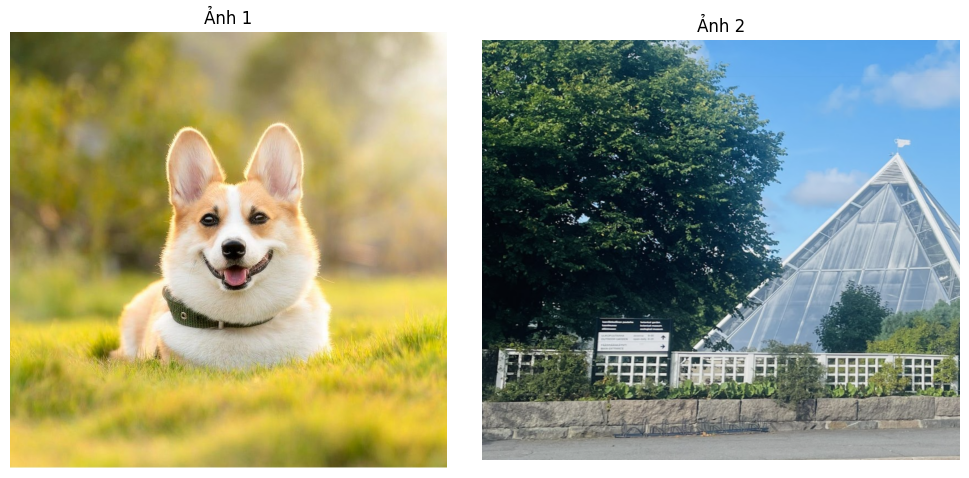


Dự đoán Top-5 cho Ảnh 1:
  Top-1: Pembroke             | p = 0.8456
  Top-2: Cardigan             | p = 0.1179
  Top-3: Eskimo dog           | p = 0.0017
  Top-4: Siberian husky       | p = 0.0008
  Top-5: wood rabbit          | p = 0.0008

Dự đoán Top-5 cho Ảnh 2:
  Top-1: greenhouse           | p = 0.8881
  Top-2: suspension bridge    | p = 0.0330
  Top-3: solar dish           | p = 0.0122
  Top-4: radio telescope      | p = 0.0058
  Top-5: dam                  | p = 0.0040

Kích thước vector SE: (144,) (144,)


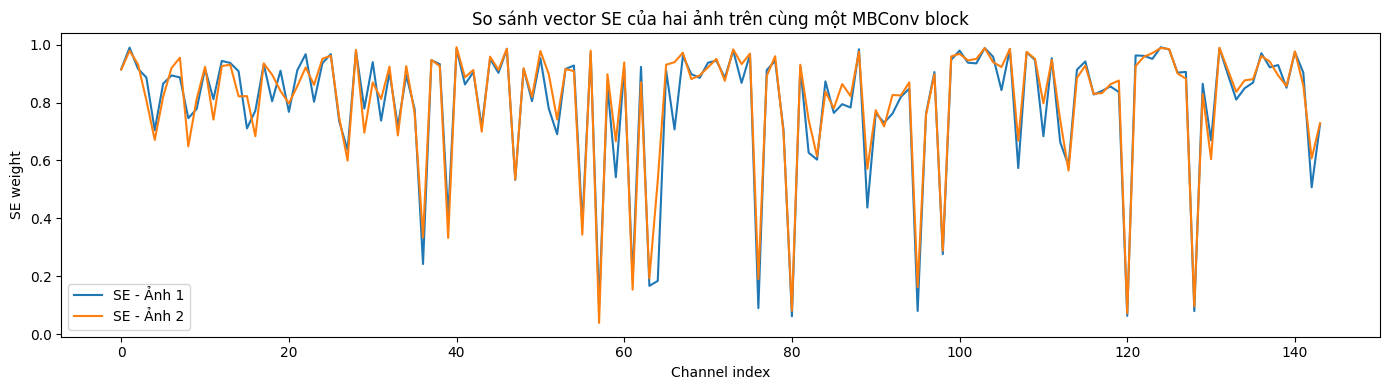

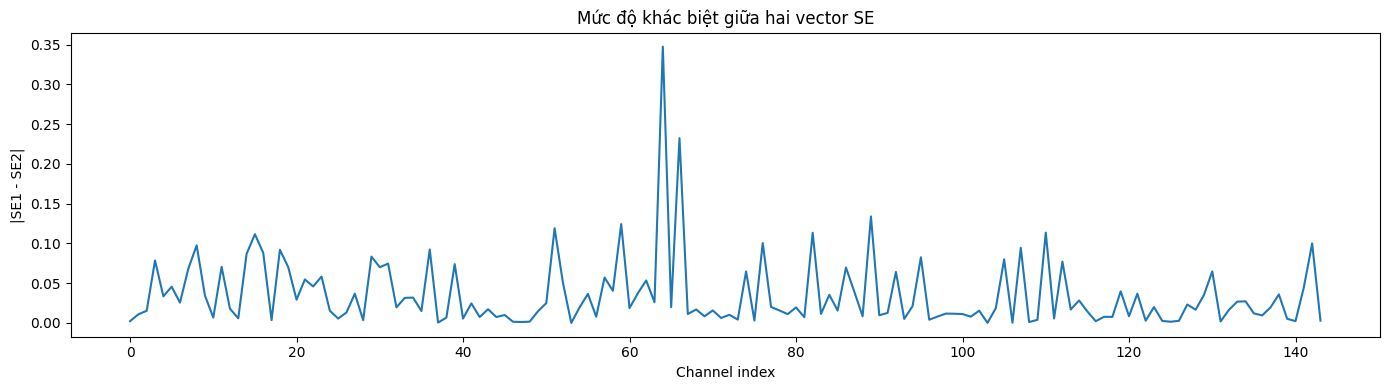


10 channel khác biệt mạnh nhất giữa hai ảnh:
[64, 66, 89, 59, 51, 110, 82, 15, 76, 142]


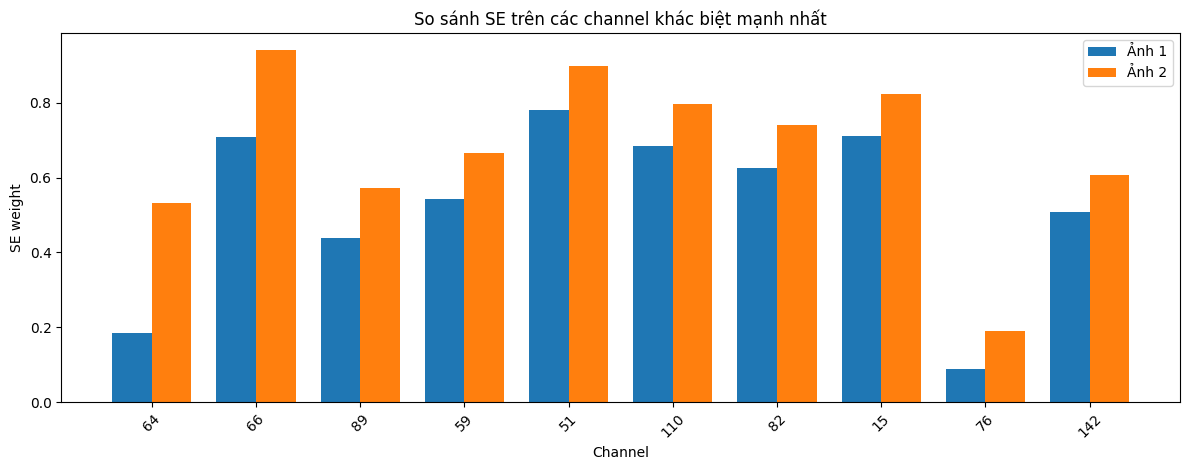

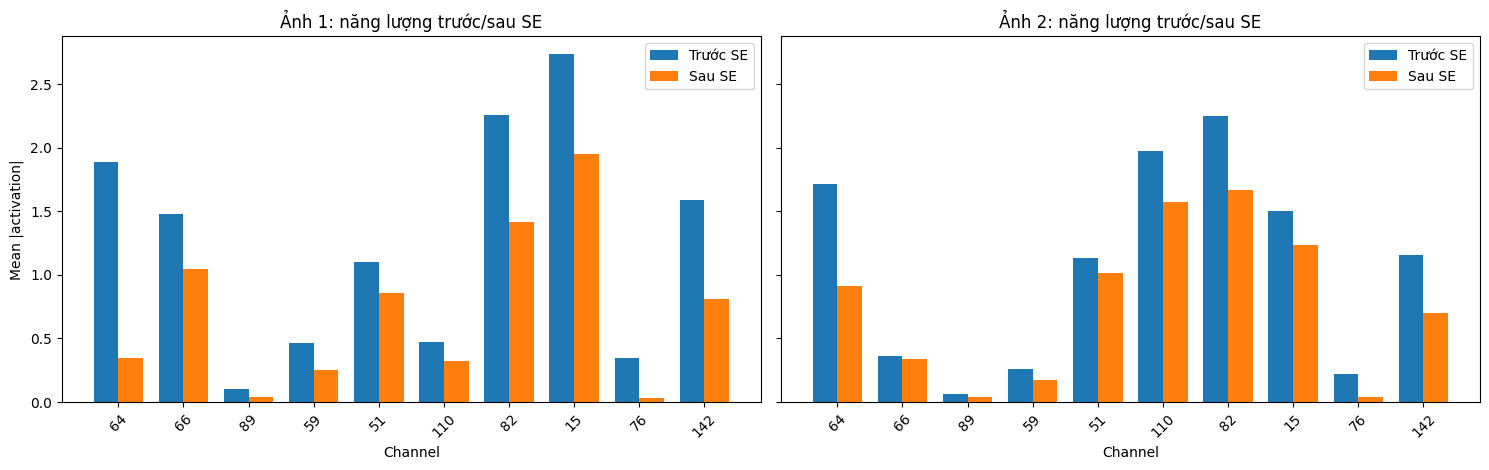


Các channel sẽ hiển thị feature maps chi tiết:
[64, 66, 89, 59, 51]


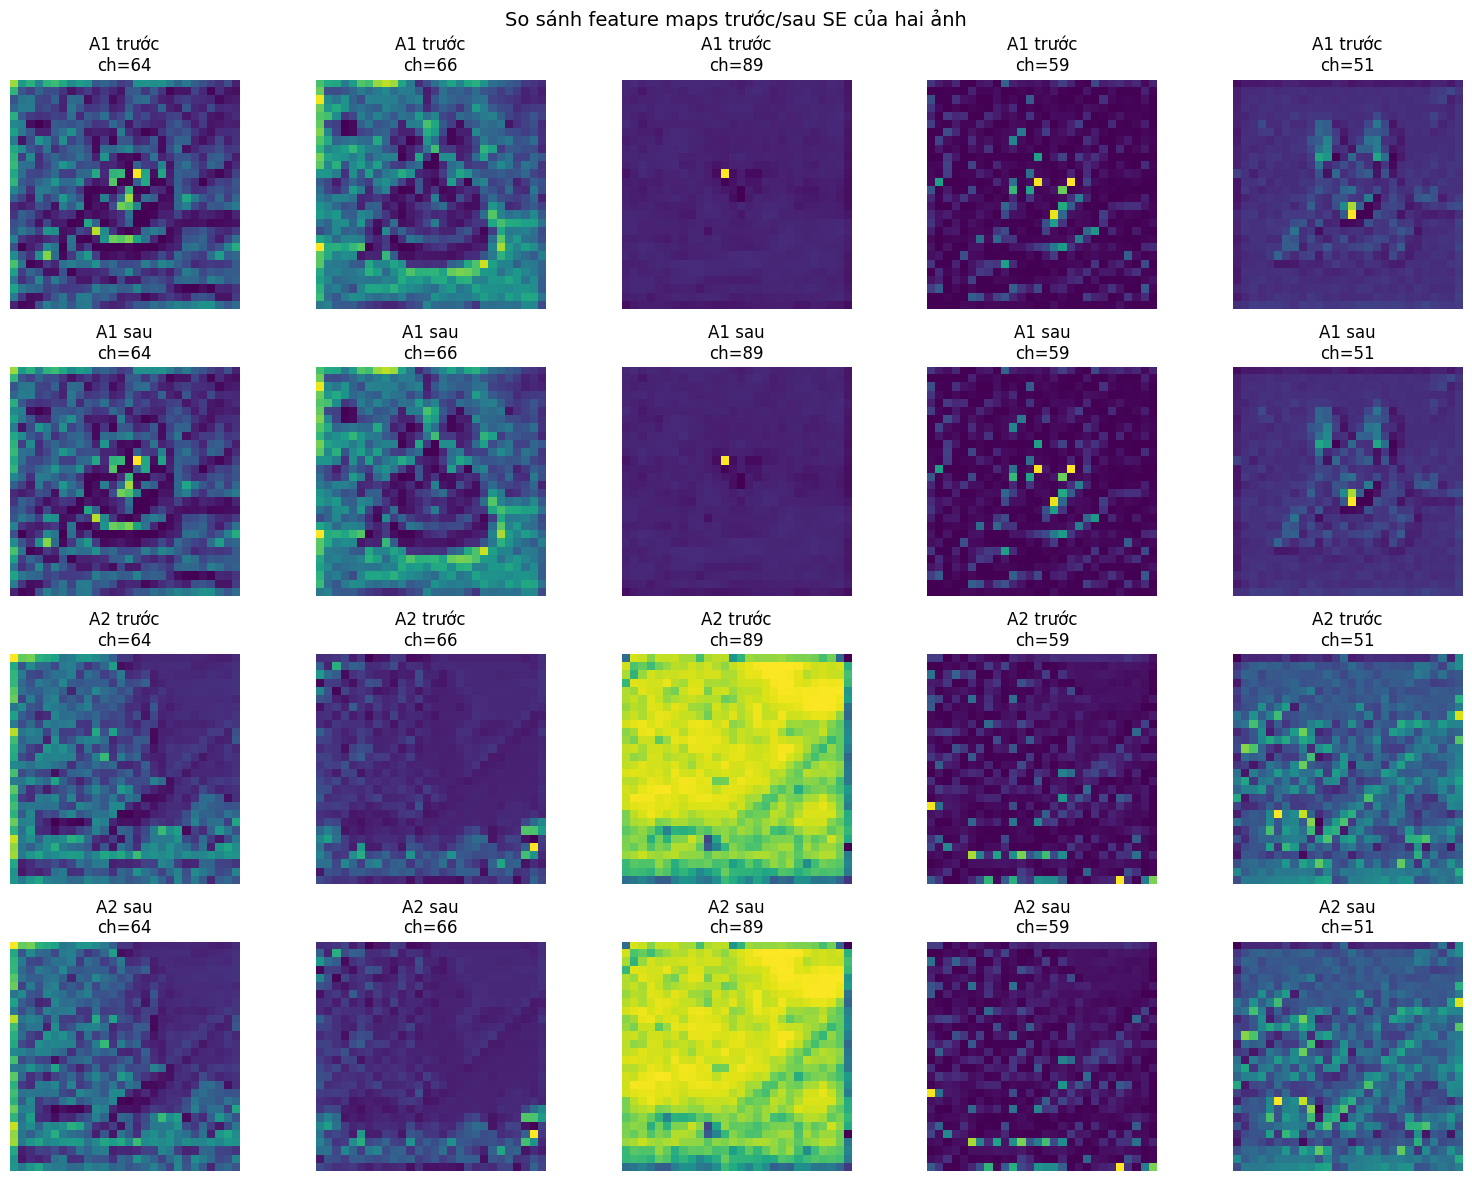


Kiểm tra kích thước và thống kê:
SE Ảnh 1: shape=(144,), min=0.0613, max=0.9917, mean=0.7945
SE Ảnh 2: shape=(144,), min=0.0384, max=0.9917, mean=0.8054
|SE1 - SE2|: min=0.0001, max=0.3475, mean=0.0352

Kết luận kiểm tra:
- Code chạy đúng nếu hai vector SE có cùng kích thước.
- Code chạy đúng nếu |SE1 - SE2| có giá trị khác 0.
- Điều này cho thấy cùng một MBConv block tạo trọng số SE khác nhau cho hai ảnh khác nhau.

Gợi ý thử nghiệm:
- Thay TARGET_MBConv_INDEX = 2, 4, 5 để quan sát SE ở các MBConv block khác nhau.
- Thay IMAGE_URL_1 hoặc IMAGE_URL_2 bằng ảnh khác để kiểm tra ảnh hưởng của nội dung đầu vào.
- Thay TOPK_DIFF_CHANNELS để xem nhiều hoặc ít channel khác biệt nhất.


In [2]:
# ============================================================
# GIÁO TRÌNH: THỊ GIÁC MÁY: TỪ XỬ LÝ ẢNH ĐẾN HỌC SÂU
# BÀI CODE MINH HỌA: SO SÁNH TÁC ĐỘNG CỦA SE TRÊN 2 ẢNH KHÁC NHAU
# Chương/Mục liên quan: Chương 7 - Mạng CNN hiện đại và cơ chế attention theo kênh
# ============================================================

# ============================================================
# MÔ TẢ
# ============================================================

# Mục đích:
# - Minh họa cơ chế Squeeze-and-Excitation trong EfficientNet-B0.
# - Chứng minh rằng SE không tạo trọng số kênh cố định.
# - Giúp người học quan sát vector SE thay đổi theo nội dung ảnh đầu vào.

# Sau khi chạy code, người học cần:
# 1. Quan sát được hai ảnh khác nhau sinh ra hai vector SE khác nhau.
# 2. Hiểu rằng SE là cơ chế attention theo kênh phụ thuộc dữ liệu đầu vào.
# 3. Thấy được feature map trước và sau SE thay đổi như thế nào.

# Input:
# - Hai ảnh màu RGB từ GitHub.
# - Mỗi ảnh được tiền xử lý theo chuẩn ImageNet của EfficientNet-B0.

# Output:
# - Hai ảnh đầu vào.
# - Dự đoán Top-5 ImageNet cho từng ảnh.
# - Vector SE của hai ảnh.
# - Độ chênh lệch giữa hai vector SE.
# - Các channel có trọng số SE khác biệt mạnh nhất.
# - Năng lượng kích hoạt trước/sau SE.
# - Feature map trước/sau SE của một số channel tiêu biểu.

# Lưu ý:
# Đoạn code này được xây dựng với sự hỗ trợ của công cụ AI.
# Giảng viên đã đọc, kiểm tra và hiệu chỉnh nhằm bảo đảm tính chính xác,
# tính sư phạm và sự phù hợp với nội dung lý thuyết trong giáo trình.

# Người học không chỉ chạy code để xem kết quả, mà cần hiểu:
# - Code đang minh họa nội dung lý thuyết nào;
# - Các bước xử lý tương ứng với công thức hoặc thuật toán nào;
# - Kết quả đầu ra có hợp lý hay không;
# - Khi thay đổi tham số, kết quả thay đổi như thế nào.


# ============================================================
# 1. CÀI ĐẶT VÀ IMPORT THƯ VIỆN
# ============================================================

import math
import requests
from io import BytesIO

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torchvision import models
from torchvision.models import EfficientNet_B0_Weights


# ============================================================
# 2. CẤU HÌNH THAM SỐ
# ============================================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42

IMAGE_URL_1 = "https://github.com/lthavnu/cv-book/raw/main/images/pembroke.jpg"
IMAGE_URL_2 = "https://github.com/lthavnu/cv-book/raw/main/images/Oulu1.png"

TARGET_MBConv_INDEX = 3
TOPK_DIFF_CHANNELS = 10

torch.manual_seed(SEED)
np.random.seed(SEED)

print("DEVICE:", DEVICE)


# ============================================================
# 3. ĐỊNH NGHĨA CÁC HÀM TIỆN ÍCH
# ============================================================

def load_image_from_url(url):
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    img = Image.open(BytesIO(response.content)).convert("RGB")
    return img


def show_two_images(img1, img2, title1="Ảnh 1", title2="Ảnh 2"):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.8))

    axes[0].imshow(img1)
    axes[0].set_title(title1)
    axes[0].axis("off")

    axes[1].imshow(img2)
    axes[1].set_title(title2)
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()


def decode_topk(logits, weights, topk=5):
    probs = torch.softmax(logits, dim=1)
    vals, inds = torch.topk(probs, k=topk, dim=1)
    categories = weights.meta["categories"]

    results = []
    for p, idx in zip(vals[0].detach().cpu().numpy(), inds[0].detach().cpu().numpy()):
        results.append((categories[idx], float(p)))

    return results


def normalize_2d_map(x):
    x = x.astype(np.float32)
    x = x - x.min()

    if x.max() > 1e-8:
        x = x / x.max()

    return x


def compute_channel_energy(feat_tensor):
    # feat_tensor có kích thước [1, C, H, W]
    feat = feat_tensor[0]
    return feat.abs().mean(dim=(1, 2)).detach().cpu().numpy()


# ============================================================
# 4. TẢI MÔ HÌNH EFFICIENTNET-B0 ĐÃ HUẤN LUYỆN TRÊN IMAGENET
# ============================================================

weights = EfficientNet_B0_Weights.IMAGENET1K_V1
model = models.efficientnet_b0(weights=weights).to(DEVICE).eval()
preprocess = weights.transforms()


# ============================================================
# 5. TÌM CÁC MBConv BLOCK CÓ CHỨA SE
# ============================================================

def find_mbconv_blocks_with_se(model):
    blocks = []

    for m in model.modules():
        if m.__class__.__name__ == "MBConv":
            se_module = None

            for sub in m.block:
                if sub.__class__.__name__ == "SqueezeExcitation":
                    se_module = sub
                    break

            if se_module is not None:
                blocks.append((m, se_module))

    return blocks


mbconv_blocks = find_mbconv_blocks_with_se(model)

print(f"Số MBConv có SE tìm được: {len(mbconv_blocks)}")

if len(mbconv_blocks) == 0:
    raise RuntimeError("Không tìm thấy MBConv block có SE trong EfficientNet-B0.")

if TARGET_MBConv_INDEX >= len(mbconv_blocks):
    raise ValueError(
        f"TARGET_MBConv_INDEX={TARGET_MBConv_INDEX} vượt số block hiện có ({len(mbconv_blocks)})."
    )

target_block, target_se = mbconv_blocks[TARGET_MBConv_INDEX]

print("\nĐã chọn MBConv block:")
print(target_block)

print("\nCác thành phần bên trong target_block.block:")
for i, sub in enumerate(target_block.block):
    print(f"  [{i}] {sub.__class__.__name__}")


# ============================================================
# 6. ĐỊNH NGHĨA HOOK ĐỂ LẤY ĐẦU VÀO CỦA TARGET BLOCK
# ============================================================

captured_block_input = None


def hook_block_input(module, inp, out):
    global captured_block_input
    captured_block_input = inp[0].detach().clone()


# ============================================================
# 7. CHẠY RIÊNG QUA MBConv BLOCK VÀ TRÍCH CÁC ĐẠI LƯỢNG CẦN QUAN SÁT
# ============================================================

def forward_through_mbconv_and_capture(block, x):
    feat_before_se = None
    se_vector = None
    feat_after_se = None

    out = x
    residual_input = x

    for sub in block.block:
        sub_name = sub.__class__.__name__

        if sub_name == "SqueezeExcitation":
            feat_before_se = out.detach().clone()

            # Dòng này tương ứng với thao tác nhân feature map với trọng số SE theo từng kênh.
            out = sub(out)

            with torch.no_grad():
                # Các dòng dưới đây tương ứng với công thức SE:
                # squeeze: z_c = GlobalAveragePooling(U_c)
                # excitation: s = sigmoid(W2 * activation(W1 * z))
                scale = sub.avgpool(feat_before_se)
                scale = sub.fc1(scale)
                scale = sub.activation(scale)
                scale = sub.fc2(scale)
                scale = sub.scale_activation(scale)

            se_vector = scale[0, :, 0, 0].detach().cpu().numpy()
            feat_after_se = out.detach().clone()

        else:
            out = sub(out)

    if getattr(block, "stochastic_depth", None) is not None:
        if block.use_res_connect:
            out = block.stochastic_depth(out)
            out = out + residual_input

    feat_after_block = out.detach().clone()

    if feat_before_se is None:
        raise RuntimeError("Không lấy được feature trước SE.")

    if se_vector is None:
        raise RuntimeError("Không lấy được vector SE.")

    if feat_after_se is None:
        raise RuntimeError("Không lấy được feature sau SE.")

    return feat_before_se, se_vector, feat_after_se, feat_after_block


# ============================================================
# 8. HÀM CHẠY MỘT ẢNH QUA MÔ HÌNH VÀ TARGET BLOCK
# ============================================================

def run_single_image(img_pil, image_name="Ảnh"):
    global captured_block_input
    captured_block_input = None

    x = preprocess(img_pil).unsqueeze(0).to(DEVICE)

    hook_handle = target_block.register_forward_hook(hook_block_input)

    with torch.no_grad():
        logits = model(x)

    hook_handle.remove()

    if captured_block_input is None:
        raise RuntimeError(f"Không bắt được đầu vào của target_block cho {image_name}.")

    with torch.no_grad():
        feat_before_se, se_vector, feat_after_se, feat_after_block = \
            forward_through_mbconv_and_capture(target_block, captured_block_input)

    top5 = decode_topk(logits, weights, topk=5)

    return {
        "image_name": image_name,
        "logits": logits,
        "top5": top5,
        "block_input": captured_block_input,
        "feat_before_se": feat_before_se,
        "se_vector": se_vector,
        "feat_after_se": feat_after_se,
        "feat_after_block": feat_after_block,
    }


# ============================================================
# 9. TẢI DỮ LIỆU ĐẦU VÀO
# ============================================================

img1 = load_image_from_url(IMAGE_URL_1)
img2 = load_image_from_url(IMAGE_URL_2)


# ============================================================
# 10. HIỂN THỊ ẢNH ĐẦU VÀO
# ============================================================

show_two_images(img1, img2, title1="Ảnh 1", title2="Ảnh 2")


# ============================================================
# 11. XỬ LÝ CHÍNH
# ============================================================

result1 = run_single_image(img1, image_name="Ảnh 1")
result2 = run_single_image(img2, image_name="Ảnh 2")


# ============================================================
# 12. HIỂN THỊ DỰ ĐOÁN TOP-5
# ============================================================

print("\nDự đoán Top-5 cho Ảnh 1:")
for i, (name, prob) in enumerate(result1["top5"], 1):
    print(f"  Top-{i}: {name:20s} | p = {prob:.4f}")

print("\nDự đoán Top-5 cho Ảnh 2:")
for i, (name, prob) in enumerate(result2["top5"], 1):
    print(f"  Top-{i}: {name:20s} | p = {prob:.4f}")


# ============================================================
# 13. TÁCH CÁC ĐẠI LƯỢNG CẦN PHÂN TÍCH
# ============================================================

se1 = result1["se_vector"]
se2 = result2["se_vector"]

feat_before_1 = result1["feat_before_se"]
feat_before_2 = result2["feat_before_se"]

feat_after_1 = result1["feat_after_se"]
feat_after_2 = result2["feat_after_se"]

energy_before_1 = compute_channel_energy(feat_before_1)
energy_before_2 = compute_channel_energy(feat_before_2)

energy_after_1 = compute_channel_energy(feat_after_1)
energy_after_2 = compute_channel_energy(feat_after_2)

print("\nKích thước vector SE:", se1.shape, se2.shape)


# ============================================================
# 14. HIỂN THỊ HAI VECTOR SE TRÊN CÙNG MỘT BIỂU ĐỒ
# ============================================================

plt.figure(figsize=(14, 4))
plt.plot(se1, label="SE - Ảnh 1")
plt.plot(se2, label="SE - Ảnh 2")
plt.xlabel("Channel index")
plt.ylabel("SE weight")
plt.title("So sánh vector SE của hai ảnh trên cùng một MBConv block")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 15. HIỂN THỊ ĐỘ CHÊNH TUYỆT ĐỐI GIỮA HAI VECTOR SE
# ============================================================

se_diff = np.abs(se1 - se2)

plt.figure(figsize=(14, 4))
plt.plot(se_diff)
plt.xlabel("Channel index")
plt.ylabel("|SE1 - SE2|")
plt.title("Mức độ khác biệt giữa hai vector SE")
plt.tight_layout()
plt.show()


# ============================================================
# 16. TÌM CÁC CHANNEL KHÁC BIỆT MẠNH NHẤT
# ============================================================

topk = min(TOPK_DIFF_CHANNELS, len(se_diff))
top_diff_channels = np.argsort(se_diff)[-topk:][::-1].tolist()

print(f"\n{topk} channel khác biệt mạnh nhất giữa hai ảnh:")
print(top_diff_channels)


# ============================================================
# 17. SO SÁNH TRỰC TIẾP SE TRÊN CÁC CHANNEL KHÁC BIỆT NHẤT
# ============================================================

x = np.arange(len(top_diff_channels))
width = 0.38

plt.figure(figsize=(12, 4.8))
plt.bar(x - width / 2, [se1[ch] for ch in top_diff_channels], width=width, label="Ảnh 1")
plt.bar(x + width / 2, [se2[ch] for ch in top_diff_channels], width=width, label="Ảnh 2")
plt.xticks(x, top_diff_channels, rotation=45)
plt.xlabel("Channel")
plt.ylabel("SE weight")
plt.title("So sánh SE trên các channel khác biệt mạnh nhất")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 18. SO SÁNH NĂNG LƯỢNG TRƯỚC/SAU SE TRÊN CÁC CHANNEL KHÁC BIỆT NHẤT
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), sharey=True)

axes[0].bar(
    x - width / 2,
    [energy_before_1[ch] for ch in top_diff_channels],
    width=width,
    label="Trước SE"
)
axes[0].bar(
    x + width / 2,
    [energy_after_1[ch] for ch in top_diff_channels],
    width=width,
    label="Sau SE"
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(top_diff_channels, rotation=45)
axes[0].set_xlabel("Channel")
axes[0].set_ylabel("Mean |activation|")
axes[0].set_title("Ảnh 1: năng lượng trước/sau SE")
axes[0].legend()

axes[1].bar(
    x - width / 2,
    [energy_before_2[ch] for ch in top_diff_channels],
    width=width,
    label="Trước SE"
)
axes[1].bar(
    x + width / 2,
    [energy_after_2[ch] for ch in top_diff_channels],
    width=width,
    label="Sau SE"
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(top_diff_channels, rotation=45)
axes[1].set_xlabel("Channel")
axes[1].set_title("Ảnh 2: năng lượng trước/sau SE")
axes[1].legend()

plt.tight_layout()
plt.show()


# ============================================================
# 19. HIỂN THỊ FEATURE MAP TRƯỚC/SAU SE CỦA MỘT SỐ CHANNEL
# ============================================================

def show_feature_pairs_two_images(
    feat_before_1,
    feat_after_1,
    feat_before_2,
    feat_after_2,
    channel_ids,
    cols=5
):
    # Hiển thị 4 hàng:
    # - Hàng 1: Ảnh 1 trước SE
    # - Hàng 2: Ảnh 1 sau SE
    # - Hàng 3: Ảnh 2 trước SE
    # - Hàng 4: Ảnh 2 sau SE

    fb1 = feat_before_1[0].detach().cpu().numpy()
    fa1 = feat_after_1[0].detach().cpu().numpy()
    fb2 = feat_before_2[0].detach().cpu().numpy()
    fa2 = feat_after_2[0].detach().cpu().numpy()

    n_channels = min(fb1.shape[0], fa1.shape[0], fb2.shape[0], fa2.shape[0])
    valid_channel_ids = [ch for ch in channel_ids if 0 <= ch < n_channels]

    if len(valid_channel_ids) == 0:
        print("[Cảnh báo] Không có channel hợp lệ để hiển thị feature maps.")
        return

    rows = 4

    plt.figure(figsize=(3.1 * len(valid_channel_ids), 3.0 * rows))

    for i, ch in enumerate(valid_channel_ids, 1):
        ax = plt.subplot(rows, len(valid_channel_ids), i)
        ax.imshow(normalize_2d_map(fb1[ch]), cmap="viridis")
        ax.set_title(f"A1 trước\nch={ch}")
        ax.axis("off")

    for i, ch in enumerate(valid_channel_ids, 1 + len(valid_channel_ids)):
        ch_id = valid_channel_ids[i - 1 - len(valid_channel_ids)]
        ax = plt.subplot(rows, len(valid_channel_ids), i)
        ax.imshow(normalize_2d_map(fa1[ch_id]), cmap="viridis")
        ax.set_title(f"A1 sau\nch={ch_id}")
        ax.axis("off")

    offset = 2 * len(valid_channel_ids)

    for i, ch in enumerate(valid_channel_ids, 1 + offset):
        ch_id = valid_channel_ids[i - 1 - offset]
        ax = plt.subplot(rows, len(valid_channel_ids), i)
        ax.imshow(normalize_2d_map(fb2[ch_id]), cmap="viridis")
        ax.set_title(f"A2 trước\nch={ch_id}")
        ax.axis("off")

    offset = 3 * len(valid_channel_ids)

    for i, ch in enumerate(valid_channel_ids, 1 + offset):
        ch_id = valid_channel_ids[i - 1 - offset]
        ax = plt.subplot(rows, len(valid_channel_ids), i)
        ax.imshow(normalize_2d_map(fa2[ch_id]), cmap="viridis")
        ax.set_title(f"A2 sau\nch={ch_id}")
        ax.axis("off")

    plt.suptitle("So sánh feature maps trước/sau SE của hai ảnh", fontsize=14)
    plt.tight_layout()
    plt.show()


channels_to_show = top_diff_channels[:5]

print("\nCác channel sẽ hiển thị feature maps chi tiết:")
print(channels_to_show)

show_feature_pairs_two_images(
    feat_before_1,
    feat_after_1,
    feat_before_2,
    feat_after_2,
    channels_to_show,
    cols=5
)


# ============================================================
# 20. KIỂM TRA KẾT QUẢ
# ============================================================

print("\nKiểm tra kích thước và thống kê:")

print(f"SE Ảnh 1: shape={se1.shape}, min={se1.min():.4f}, max={se1.max():.4f}, mean={se1.mean():.4f}")
print(f"SE Ảnh 2: shape={se2.shape}, min={se2.min():.4f}, max={se2.max():.4f}, mean={se2.mean():.4f}")
print(f"|SE1 - SE2|: min={se_diff.min():.4f}, max={se_diff.max():.4f}, mean={se_diff.mean():.4f}")

assert se1.shape == se2.shape, "Hai vector SE phải có cùng kích thước."
assert np.max(se_diff) > 0, "Hai vector SE không được giống hệt nhau."
assert len(top_diff_channels) > 0, "Không tìm được channel khác biệt."

print("\nKết luận kiểm tra:")
print("- Code chạy đúng nếu hai vector SE có cùng kích thước.")
print("- Code chạy đúng nếu |SE1 - SE2| có giá trị khác 0.")
print("- Điều này cho thấy cùng một MBConv block tạo trọng số SE khác nhau cho hai ảnh khác nhau.")


# ============================================================
# 21. GỢI Ý THỬ NGHIỆM CHO NGƯỜI HỌC
# ============================================================

print("\nGợi ý thử nghiệm:")
print("- Thay TARGET_MBConv_INDEX = 2, 4, 5 để quan sát SE ở các MBConv block khác nhau.")
print("- Thay IMAGE_URL_1 hoặc IMAGE_URL_2 bằng ảnh khác để kiểm tra ảnh hưởng của nội dung đầu vào.")
print("- Thay TOPK_DIFF_CHANNELS để xem nhiều hoặc ít channel khác biệt nhất.")